In [ ]:
import requests
import pandas as pd
import time

# Put your details here
API_KEY = "API KEY"  # paste your Steam API key
STEAM_ID = "STEAM ID"  # we'll get this in a sec

In [ ]:
url = f"http://api.steampowered.com/ISteamUser/GetPlayerSummaries/v0002/?key={API_KEY}&steamids={STEAM_ID}"

response = requests.get(url)

print(response.status_code)
print(response.json())

200
{'response': {'players': [{'steamid': '76561198851054675', 'communityvisibilitystate': 3, 'profilestate': 1, 'personaname': 'Nafu', 'profileurl': 'https://steamcommunity.com/profiles/76561198851054675/', 'avatar': 'https://avatars.steamstatic.com/1572d6909675e3ec691b81f796a3c0e607231e76.jpg', 'avatarmedium': 'https://avatars.steamstatic.com/1572d6909675e3ec691b81f796a3c0e607231e76_medium.jpg', 'avatarfull': 'https://avatars.steamstatic.com/1572d6909675e3ec691b81f796a3c0e607231e76_full.jpg', 'avatarhash': '1572d6909675e3ec691b81f796a3c0e607231e76', 'lastlogoff': 1778746616, 'personastate': 1, 'primaryclanid': '103582791429521408', 'timecreated': 1533036059, 'personastateflags': 0, 'loccountrycode': 'MY'}]}}


In [ ]:
games_url = f"http://api.steampowered.com/IPlayerService/GetOwnedGames/v0001/?key={API_KEY}&steamid={STEAM_ID}&include_appinfo=true&format=json"

games_response = requests.get(games_url)

games_data = games_response.json()

print(games_data)

{'response': {'game_count': 39, 'games': [{'appid': 70, 'name': 'Half-Life', 'playtime_forever': 38, 'img_icon_url': '95be6d131fc61f145797317ca437c9765f24b41c', 'playtime_windows_forever': 38, 'playtime_mac_forever': 0, 'playtime_linux_forever': 0, 'playtime_deck_forever': 0, 'rtime_last_played': 1700388539, 'content_descriptorids': [2, 5], 'playtime_disconnected': 0}, {'appid': 550, 'name': 'Left 4 Dead 2', 'playtime_forever': 301, 'img_icon_url': '7d5a243f9500d2f8467312822f8af2a2928777ed', 'has_community_visible_stats': True, 'playtime_windows_forever': 301, 'playtime_mac_forever': 0, 'playtime_linux_forever': 0, 'playtime_deck_forever': 0, 'rtime_last_played': 1601726485, 'content_descriptorids': [2, 5], 'playtime_disconnected': 0}, {'appid': 108600, 'name': 'Project Zomboid', 'playtime_2weeks': 477, 'playtime_forever': 17088, 'img_icon_url': '2bd4642ae337e378e7b04a19d19683425c5f81a4', 'playtime_windows_forever': 17088, 'playtime_mac_forever': 0, 'playtime_linux_forever': 0, 'playti

In [ ]:
games_list = games_data['response']['games']

df = pd.DataFrame(games_list)

df['playtime_hours'] = df['playtime_forever'] / 60

df = df[['name', 'playtime_forever', 'playtime_hours']]

df = df.sort_values(by='playtime_hours', ascending=False)

df = df.reset_index(drop=True)

df

,name,playtime_forever,playtime_hours
0,NARAKA: BLADEPOINT,24475,407.916667
1,Street Fighter V,23082,384.700000
2,Project Zomboid,17088,284.800000
3,Stardew Valley,5956,99.266667
4,GUILTY GEAR -STRIVE-,4916,81.933333
5,NARUTO TO BORUTO: SHINOBI STRIKER,3236,53.933333
6,Assassin's Creed Unity,2026,33.766667
7,GUILTY GEAR XX ACCENT CORE PLUS R,1788,29.800000
8,BlazBlue Centralfiction,1784,29.733333
9,STAR WARS Jedi: Fallen Order™,989,16.483333


In [ ]:
df[df['name'].str.contains('Hero', case=False)]

,name,playtime_forever,playtime_hours
18,MY HERO ONE'S JUSTICE 2,203,3.383333


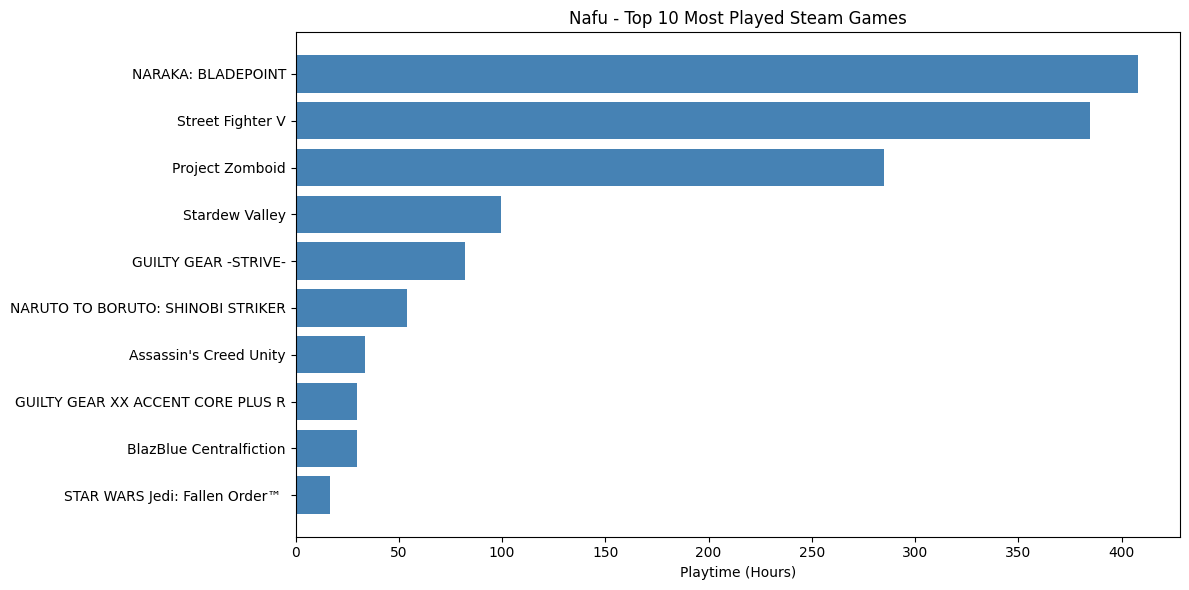

In [ ]:
import matplotlib.pyplot as plt

top10 = df.head(10)

plt.figure(figsize=(12, 6))

plt.barh(top10['name'], top10['playtime_hours'], color='steelblue')

plt.xlabel('Playtime (Hours)')
plt.title('Nafu - Top 10 Most Played Steam Games')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

INSIGHT:



**1.   What does this tell me?**

Most of my top 10 games are fighting genre


**2. Why is this happening?**

Because I love fighting games
Anyone looking at the visual can assume I'm a fighting game fan


**3. What should I look at next?**

Top 2 games (NARAKA & Street Fighter V) have significantly more hours than the rest
Shows that fighting games take up a huge chunk of my total playtime

# **Last played analysis — which games did I abandon vs still playing?**

In [ ]:
import datetime

df_full = pd.DataFrame(games_list)

df_full['playtime_hours'] = df_full['playtime_forever'] / 60

df_full['last_played'] = pd.to_datetime(df_full['rtime_last_played'], unit='s')

today = pd.Timestamp.now()

df_full['days_since_played'] = (today - df_full['last_played']).dt.days

df_full = df_full[['name', 'playtime_hours', 'last_played', 'days_since_played']]

df_full = df_full[df_full['playtime_hours'] > 0]

df_full = df_full.sort_values(by='days_since_played', ascending=True)

df_full = df_full.reset_index(drop=True)

df_full

,name,playtime_hours,last_played,days_since_played
0,Project Zomboid,284.800000,2026-05-07 11:07:49,6
1,Stardew Valley,99.266667,2026-04-22 07:54:42,22
2,MY HERO ONE'S JUSTICE 2,3.383333,2026-04-22 04:27:30,22
3,The Guild 3,1.466667,2026-03-19 15:51:13,55
4,NARUTO TO BORUTO: SHINOBI STRIKER,53.933333,2025-12-25 16:04:23,139
5,Assassin's Creed Unity,33.766667,2025-12-18 14:47:09,146
6,STAR WARS Jedi: Fallen Order™,16.483333,2025-08-13 12:44:30,273
7,UNDER NIGHT IN-BIRTH Exe:Late[cl-r],0.816667,2025-08-05 12:19:57,281
8,Street Fighter V,384.700000,2025-08-05 05:50:56,282
9,NARUTO SHIPPUDEN: Ultimate Ninja STORM 4,3.983333,2025-04-18 09:08:09,391


In [ ]:
steam_profile = response.json()['response']['players'][0]

print(steam_profile)

{'steamid': '76561198851054675', 'communityvisibilitystate': 3, 'profilestate': 1, 'personaname': 'Nafu', 'profileurl': 'https://steamcommunity.com/profiles/76561198851054675/', 'avatar': 'https://avatars.steamstatic.com/1572d6909675e3ec691b81f796a3c0e607231e76.jpg', 'avatarmedium': 'https://avatars.steamstatic.com/1572d6909675e3ec691b81f796a3c0e607231e76_medium.jpg', 'avatarfull': 'https://avatars.steamstatic.com/1572d6909675e3ec691b81f796a3c0e607231e76_full.jpg', 'avatarhash': '1572d6909675e3ec691b81f796a3c0e607231e76', 'lastlogoff': 1778746616, 'personastate': 1, 'primaryclanid': '103582791429521408', 'timecreated': 1533036059, 'personastateflags': 0, 'loccountrycode': 'MY'}


In [ ]:
account_created = pd.to_datetime(steam_profile['timecreated'], unit='s')

today = pd.Timestamp.now()

account_age = (today - account_created).days

print(f"Steam account created on: {account_created.date()}")
print(f"Account age: {account_age} days")
print(f"That is roughly {round(account_age / 365, 1)} years")

Steam account created on: 2018-07-31
Account age: 2843 days
That is roughly 7.8 years


In [ ]:
appid = 413150  # Stardew Valley

url = f"https://store.steampowered.com/api/appdetails?appids={appid}&cc=us&l=en"
response = requests.get(url)
data = response.json()

print(data)

{'413150': {'success': True, 'data': {'type': 'game', 'name': 'Stardew Valley', 'steam_appid': 413150, 'required_age': 0, 'is_free': False, 'controller_support': 'full', 'dlc': [440820], 'detailed_description': 'Stardew Valley is an open-ended country-life RPG! <br><br> <span class="bb_img_ctn"><img class="bb_img" src="https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/413150/extras/4aa7123b7bff518a6c3b640f51feb310.avif?t=1754692865" width=600 height=105 /></span><br><br>You\'ve inherited your grandfather\'s old farm plot in Stardew Valley. Armed with hand-me-down tools and a few coins, you set out to begin your new life. Can you learn to live off the land and turn these overgrown fields into a thriving home? It won\'t be easy. Ever since Joja Corporation came to town, the old ways of life have all but disappeared. The community center, once the town\'s most vibrant hub of activity, now lies in shambles. But the valley seems full of opportunity. With a little dedication

In [ ]:
import time
import requests
import pandas as pd

# Rebuild df_full with appid
df_full = pd.DataFrame(games_list)
df_full['playtime_hours'] = df_full['playtime_forever'] / 60
df_full['last_played'] = pd.to_datetime(df_full['rtime_last_played'], unit='s')
today = pd.Timestamp.now()
df_full['days_since_played'] = (today - df_full['last_played']).dt.days
df_full = df_full[['appid', 'name', 'playtime_hours', 'last_played', 'days_since_played']]
df_full = df_full[df_full['playtime_hours'] > 0]
df_full = df_full.sort_values(by='days_since_played', ascending=True)
df_full = df_full.reset_index(drop=True)

# Fetch genres
genre_map = {}

for index, row in df_full.iterrows():
    appid = int(row['appid'])
    url = f"https://store.steampowered.com/api/appdetails?appids={appid}&cc=us&l=en"
    response = requests.get(url)
    data = response.json()

    try:
        genre_list = [g['description'] for g in data[str(appid)]['data']['genres']]
        genre = ', '.join(genre_list)
    except Exception as e:
        genre = 'Unknown'
        print(f"❌ {row['name']} failed: {e}")

    genre_map[appid] = genre
    print(f"✅ {row['name']} — {genre}")
    time.sleep(2)

df_full['genre'] = df_full['appid'].map(genre_map)
df_full[['name', 'genre']]

✅ Project Zomboid — Indie, RPG, Simulation, Early Access
✅ Stardew Valley — Indie, RPG, Simulation
✅ MY HERO ONE'S JUSTICE 2 — Action
✅ The Guild 3 — RPG, Simulation, Strategy
✅ NARUTO TO BORUTO: SHINOBI STRIKER — Action
✅ Assassin's Creed Unity — Action, Adventure
✅ STAR WARS Jedi: Fallen Order™  — Action, Adventure
✅ UNDER NIGHT IN-BIRTH Exe:Late[cl-r] — Action
✅ Street Fighter V — Action
✅ NARUTO SHIPPUDEN: Ultimate Ninja STORM 4 — Action, Adventure
✅ DRAGON BALL FighterZ — Action
✅ BlazBlue Centralfiction — Action
✅ GUILTY GEAR -STRIVE- — Action
✅ The Crew 2 — Action, Massively Multiplayer, Racing
✅ Hacknet — Indie, Simulation
✅ NARAKA: BLADEPOINT — Action, Adventure, Massively Multiplayer, Free To Play
✅ Overcooked! 2 — Action, Casual, Indie
✅ GUILTY GEAR XX ACCENT CORE PLUS R — Action
✅ Tribes of Midgard — Action, Adventure, Indie, RPG
✅ Half-Life — Action
✅ Granblue Fantasy: Versus — Action
✅ FOR HONOR — Action
✅ JUMP FORCE — Action
✅ LoveChoice — Adventure, Indie, RPG, Simulati

,name,genre
0,Project Zomboid,"Indie, RPG, Simulation, Early Access"
1,Stardew Valley,"Indie, RPG, Simulation"
2,MY HERO ONE'S JUSTICE 2,Action
3,The Guild 3,"RPG, Simulation, Strategy"
4,NARUTO TO BORUTO: SHINOBI STRIKER,Action
5,Assassin's Creed Unity,"Action, Adventure"
6,STAR WARS Jedi: Fallen Order™,"Action, Adventure"
7,UNDER NIGHT IN-BIRTH Exe:Late[cl-r],Action
8,Street Fighter V,Action
9,NARUTO SHIPPUDEN: Ultimate Ninja STORM 4,"Action, Adventure"


In [ ]:
all_genres = df_full['genre'].str.split(', ').explode()

genre_counts = all_genres.value_counts()

print(genre_counts)

genre
Action                   23
Adventure                 8
Indie                     6
Simulation                5
RPG                       5
Massively Multiplayer     2
Early Access              1
Strategy                  1
Racing                    1
Free To Play              1
Casual                    1
Name: count, dtype: int64


The Highest genre count for this player is Action.
So we can assume that this player loves action game.
So as a seller we know that we can make campaign related to action genre.

In [ ]:
# Explode genres and match with playtime
df_exploded = df_full.assign(genre=df_full['genre'].str.split(', ')).explode('genre')

# Group by genre and sum playtime
genre_playtime = df_exploded.groupby('genre')['playtime_hours'].sum().sort_values(ascending=False)

print(genre_playtime)

genre
Action                   1090.733333
Adventure                 469.850000
Massively Multiplayer     409.650000
Free To Play              407.916667
Indie                     394.333333
Simulation                392.466667
RPG                       386.266667
Early Access              284.800000
Casual                      2.866667
Racing                      1.733333
Strategy                    1.466667
Name: playtime_hours, dtype: float64


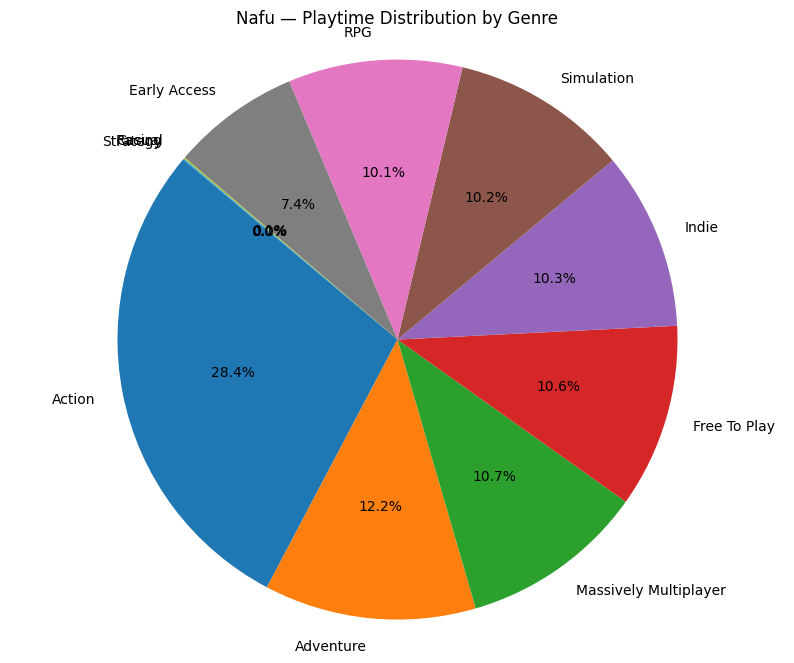

In [ ]:
plt.figure(figsize=(10, 8))

plt.pie(genre_playtime.values,
        labels=genre_playtime.index,
        autopct='%1.1f%%',
        startangle=140)

plt.title('Nafu — Playtime Distribution by Genre')
plt.axis('equal')
plt.show()

Top 3 genre:
1. Action
2. Adventure
3. Massively Multiplayer


Action dominates mostly because Steam labels fighting games as Action. The high Free to Play playtime suggests this player is a low spender — probably a student or not working yet.

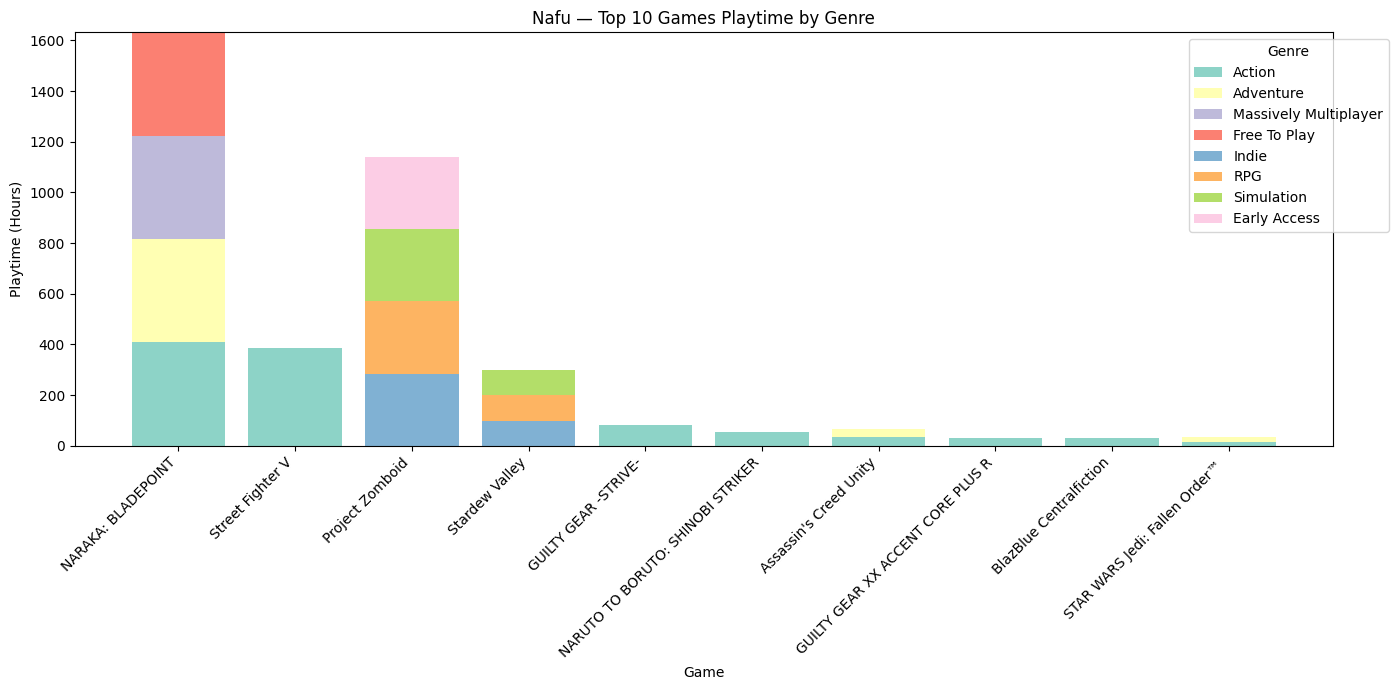

In [ ]:
# Get top 10 games by playtime
top10 = df_full.nlargest(10, 'playtime_hours')

# Explode genres for top 10
top10_exploded = top10.assign(genre=top10['genre'].str.split(', ')).explode('genre')

# Get unique genres for coloring
unique_genres = top10_exploded['genre'].unique()

# Create color map
colors = plt.cm.Set3.colors
genre_color = {genre: colors[i % len(colors)] for i, genre in enumerate(unique_genres)}

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

bottom = pd.Series([0.0] * len(top10), index=top10.index)

for genre in unique_genres:
    genre_data = top10_exploded[top10_exploded['genre'] == genre].set_index('name')['playtime_hours']
    genre_data = genre_data.reindex(top10['name']).fillna(0) / top10_exploded.groupby('name')['playtime_hours'].first().reindex(top10['name'])
    heights = top10.set_index('name')['playtime_hours'] * genre_data.values
    ax.bar(top10['name'], heights, bottom=bottom.values, label=genre, color=genre_color[genre])
    bottom = bottom + heights.values

ax.set_xlabel('Game')
ax.set_ylabel('Playtime (Hours)')
ax.set_title('Nafu — Top 10 Games Playtime by Genre')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()